In [1]:
import os
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [3]:
image_train = "/kaggle/input/datasets/ketkirahegaonkar/classifydataset/kaggle/working/CliniScan/images/train"
label_train = "/kaggle/input/datasets/ketkirahegaonkar/classifydataset/kaggle/working/CliniScan/labels/train"

output_train = "/kaggle/working/classification_data/train"

os.makedirs(output_train, exist_ok=True)

for img_name in os.listdir(image_train):
    label_file = img_name.replace(".png", ".txt")
    label_path = os.path.join(label_train, label_file)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            class_id = f.readline().split()[0]

        class_folder = os.path.join(output_train, class_id)
        os.makedirs(class_folder, exist_ok=True)

        shutil.copy(
            os.path.join(image_train, img_name),
            os.path.join(class_folder, img_name)
        )

print("Train Done ✅")

Train Done ✅


In [4]:
image_val = "/kaggle/input/datasets/ketkirahegaonkar/classifydataset/kaggle/working/CliniScan/images/val"
label_val = "/kaggle/input/datasets/ketkirahegaonkar/classifydataset/kaggle/working/CliniScan/labels/val"

output_val = "/kaggle/working/classification_data/val"

os.makedirs(output_val, exist_ok=True)

for img_name in os.listdir(image_val):
    label_file = img_name.replace(".png", ".txt")
    label_path = os.path.join(label_val, label_file)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            class_id = f.readline().split()[0]

        class_folder = os.path.join(output_val, class_id)
        os.makedirs(class_folder, exist_ok=True)

        shutil.copy(
            os.path.join(image_val, img_name),
            os.path.join(class_folder, img_name)
        )

print("Val Done ✅")

Val Done ✅


In [5]:
train_data = datasets.ImageFolder(
    "/kaggle/working/classification_data/train",
    transform=transform
)

val_data = datasets.ImageFolder(
    "/kaggle/working/classification_data/val",
    transform=transform
)

In [6]:
train_loader = DataLoader(train_data, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=8, num_workers=0)

print("Loader Ready ✅")

Loader Ready ✅


In [7]:
model = models.densenet121(pretrained=True)

model.classifier = nn.Linear(model.classifier.in_features, len(train_data.classes))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model Ready ✅")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s]


Model Ready ✅


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(3):
    model.train()
    running_loss = 0

    print(f"Starting Epoch {epoch+1}")

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Starting Epoch 1
Epoch 1, Loss: 471.7733
Starting Epoch 2
Epoch 2, Loss: 471.6849
Starting Epoch 3
Epoch 3, Loss: 471.8650


In [9]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 18.048780487804876


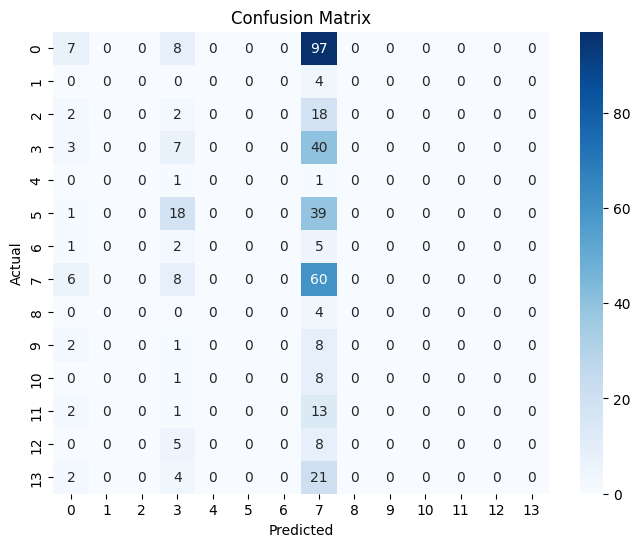

              precision    recall  f1-score   support

           0       0.27      0.06      0.10       112
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00        22
           3       0.12      0.14      0.13        50
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00        58
           6       0.00      0.00      0.00         8
           7       0.18      0.81      0.30        74
           8       0.00      0.00      0.00         4
           9       0.00      0.00      0.00        11
          10       0.00      0.00      0.00         9
          11       0.00      0.00      0.00        16
          12       0.00      0.00      0.00        13
          13       0.00      0.00      0.00        27

    accuracy                           0.18       410
   macro avg       0.04      0.07      0.04       410
weighted avg       0.12      0.18      0.10       410

AUC Score: 0.565423561627

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# F1 Score
print(classification_report(y_true, y_pred))

# AUC
auc = roc_auc_score(np.array(y_true), np.array(y_prob), multi_class='ovr')
print("AUC Score:", auc)